In [60]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

motif_length = 3
persite_mu = 1.34*10**(-8)

In [61]:
#Total sites refer to the total amount across all regions considered
def get_normalizer_mut_constant(mutability_data, persite_mu):
    #Calculate the constant to normalize the total mutation rate equal to the average per base mutation rate
    # mutability_data is a data frame with the mutability, regions, chromosome and sequence length
    # mean_mutability is the average relative mutation rate of a genomic region

    #multiply each mutability score by it's length to obtain a weighted sum
    mutTimeslength = np.sum(mutability_data["mean_mutability"]*mutability_data["numb_sites"])
    total_numb_sites = mutability_data["numb_sites"].sum()

    #divide by the total number of sites to obtain the average mutability score across all sites
    mean_mutability = mutTimeslength/total_numb_sites

    #mu = c*mutability. Divide mean_mu/mean_mutability to obtain the constant
    constant_mu = persite_mu/mean_mutability

    return constant_mu

In [62]:
df = pd.read_csv("output_data/mutability_motiflength" + str(motif_length) + ".csv")
df

,Region,Chromosome,mean_mutability,numb_sites
0,cds,1,0.716698,3267138
1,introns_nonUTR,1,0.519656,55059024
2,introns3UTR,1,0.669294,650415
3,introns5UTR,1,0.673571,689064
4,intronsAR,1,0.535451,116436765
...,...,...,...,...
179,introns5UTR,X,0.632280,259638
180,intronsAR,X,0.517126,52711425
181,distalIG,X,0.487814,51798978
182,proximal5IG,X,0.521340,5427300


/tmp/ipykernel_2625237/1462388849.py:31: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=12)
/tmp/ipykernel_2625237/1462388849.py:32: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


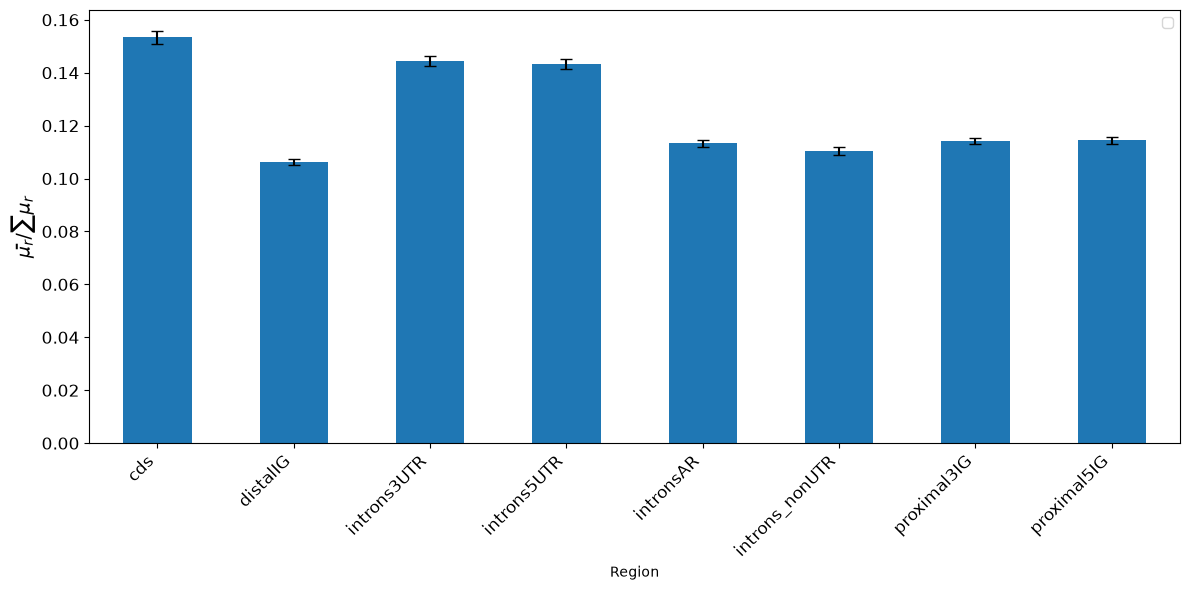

In [63]:
constant_mu = get_normalizer_mut_constant(df, persite_mu)

mutability_data = df.drop(columns=['numb_sites'], errors='ignore')

mutationrate_data = mutability_data.copy()
mutationrate_data["mean_mutation_rate"] = mutationrate_data["mean_mutability"]*constant_mu
mutationrate_data = mutationrate_data[["Region", "Chromosome", "mean_mutation_rate"]]
stats_mutrate = mutationrate_data.groupby(['Region'])['mean_mutation_rate'].agg(['mean', 'sem']).unstack()

sum_of_means = stats_mutrate.loc["mean"].sum()

#I'm computing the relative contribution of a region mutation rate compared to the total sum of mu. 
relative_mutationrate_data = mutationrate_data.copy()
relative_mutationrate_data["relative_mean_mutation_rate"] = relative_mutationrate_data["mean_mutation_rate"]/sum_of_means
relative_mutationrate_data = relative_mutationrate_data[["Region", "Chromosome", "relative_mean_mutation_rate"]]

stats_relative_mutrate = relative_mutationrate_data.groupby(['Region'])['relative_mean_mutation_rate'].agg(['mean', 'sem']).unstack()

mean_relative_mutationrate_data = stats_relative_mutrate['mean']
err_relative_mutationrate_data = stats_relative_mutrate['sem']

ax = mean_relative_mutationrate_data.plot(
    kind='bar',
    yerr=err_relative_mutationrate_data,
    capsize=4,
    figsize=(12, 6)
)
ax.set_ylabel(r'$\bar{\mu_r}/\sum\mu_r$', fontsize=14)
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)
ax.legend(fontsize=12)
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [64]:
stats_mutrate.to_csv("output_data/average_mutrates_motiflength" + str(motif_length) + "_mean_sem.csv")
stats_mutrate

      Region        
mean  cds               1.863071e-08
      distalIG          1.291262e-08
      introns3UTR       1.756165e-08
      introns5UTR       1.740631e-08
      intronsAR         1.377059e-08
      introns_nonUTR    1.342659e-08
      proximal3IG       1.388788e-08
      proximal5IG       1.389671e-08
sem   cds               3.101812e-10
      distalIG          1.303278e-10
      introns3UTR       2.346753e-10
      introns5UTR       2.185244e-10
      intronsAR         1.591458e-10
      introns_nonUTR    1.773592e-10
      proximal3IG       1.452402e-10
      proximal5IG       1.418784e-10
dtype: float64

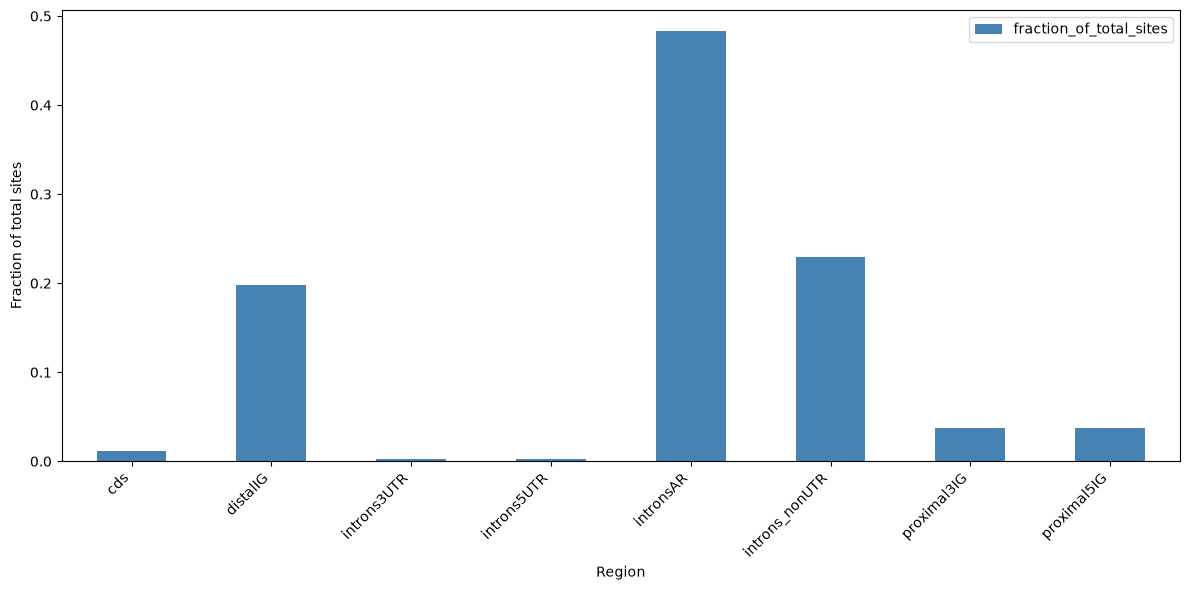

In [65]:
length_data = df.drop(columns=['mean_mutability'], errors='ignore')

total_numb_sites = length_data["numb_sites"].sum()

region_numb_sites = (
    length_data.groupby("Region", as_index=False)["numb_sites"]
    .sum()
    .rename(columns={"numb_sites": "total_numb_sites"})
)

region_numb_sites["fraction_of_total_sites"] = (
    region_numb_sites["total_numb_sites"] / total_numb_sites
)

ax = region_numb_sites.plot(
    x="Region",
    y="fraction_of_total_sites",
    kind="bar",
    figsize=(12, 6),
    color="steelblue"
)

ax.set_ylabel("Fraction of total sites")
ax.set_xlabel("Region")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [66]:
region_numb_sites.to_csv("output_data/length_perregion.csv")
region_numb_sites

,Region,total_numb_sites,fraction_of_total_sites
0,cds,32311749,0.011633
1,distalIG,548608197,0.197507
2,introns3UTR,6675828,0.002403
3,introns5UTR,6709323,0.002415
4,intronsAR,1340744649,0.482687
5,introns_nonUTR,635749401,0.228879
6,proximal3IG,103451304,0.037244
7,proximal5IG,103420896,0.037233


# Test that the average mutation rate is correct

In [67]:
mean_mutrate = sum(mutationrate_data["mean_mutation_rate"]*length_data["numb_sites"])/sum(length_data["numb_sites"])
mean_mutrate

1.3400000000000003e-08